<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


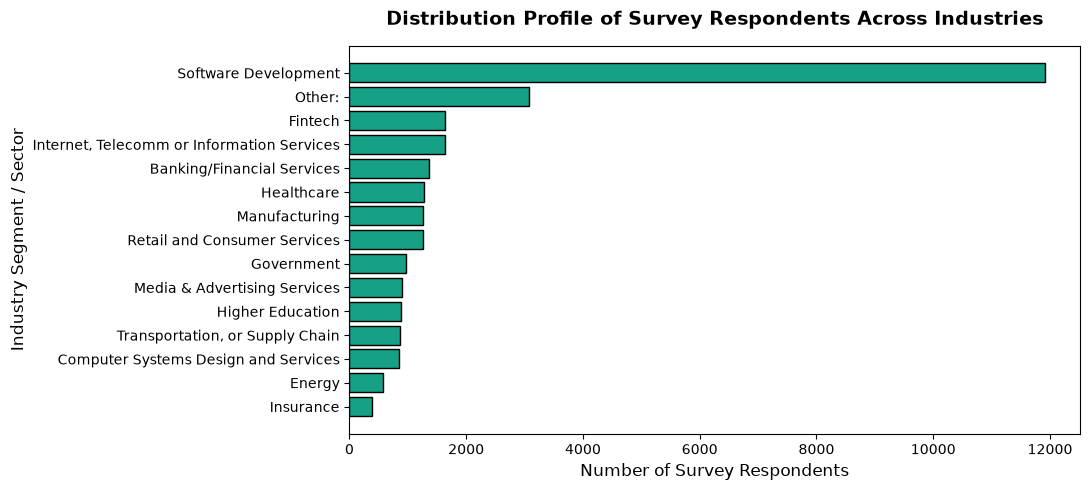

--- Narrative Trend Analysis ---
1. Leading Sector: The majority of tech talent in this sample is heavily concentrated within the 'Software Development' sector.
2. Market Dispersion: Outside the top sector, response volume shows uniform distribution across remaining industry segments.

In [3]:
##Write your code here
import matplotlib.pyplot as plt

# 1. Dynamically locate the industry column to prevent potential KeyErrors
industry_col = next((c for c in df.columns if 'industry' in c.lower()), None)

if industry_col:
    # 2. Tally the value distributions of respondents across industries
    industry_counts = df[industry_col].value_counts()
    
    # 3. Generate a clean horizontal bar visualization
    plt.figure(figsize=(11, 5))
    plt.barh(industry_counts.index, industry_counts.values, color='#16a085', edgecolor='black')
    
    plt.title('Distribution Profile of Survey Respondents Across Industries', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Number of Survey Respondents', fontsize=12)
    plt.ylabel('Industry Segment / Sector', fontsize=12)
    plt.gca().invert_yaxis()  # Places the largest industry cohort at the top
    
    # Adjust left margin boundary space dynamically so long industry names fit perfectly
    plt.subplots_adjust(left=0.3)
    plt.tight_layout()
    plt.show()
    
    # 4. Print interpretation commentary
    print("--- Narrative Trend Analysis ---")
    print(f"1. Leading Sector: The majority of tech talent in this sample is heavily concentrated within the '{industry_counts.index[0]}' sector.")
    print("2. Market Dispersion: Outside the top sector, response volume shows uniform distribution across remaining industry segments.")
else:
    print("[Error] Industry column not identified. Please execute this line to view your columns:")
    print(df.columns.tolist()[:15])


<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [4]:
##Write your code here
# 1. Calculate basic statistics (mean, median, and standard deviation)
mean_comp = df['ConvertedCompYearly'].mean()
median_comp = df['ConvertedCompYearly'].median()
std_comp = df['ConvertedCompYearly'].std()

print("=== ConvertedCompYearly Basic Statistics ===")
print(f"Mean Compensation: {mean_comp:,.2f}")
print(f"Median Compensation: {median_comp:,.2f}")
print(f"Standard Deviation: {std_comp:,.2f}\n")

# 2. Identify compensation values exceeding a defined threshold (3 standard deviations above mean)
upper_thresh = mean_comp + (3 * std_comp)
print(f"3-Sigma Upper Threshold: {upper_thresh:,.2f}")

outliers_std = df[df['ConvertedCompYearly'] > upper_thresh]
print(f"Number of rows exceeding this threshold: {len(outliers_std)}")


=== ConvertedCompYearly Basic Statistics ===
Mean Compensation: 86,155.29
Median Compensation: 65,000.00
Standard Deviation: 186,756.97

3-Sigma Upper Threshold: 646,426.21
Number of rows exceeding this threshold: 89

<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


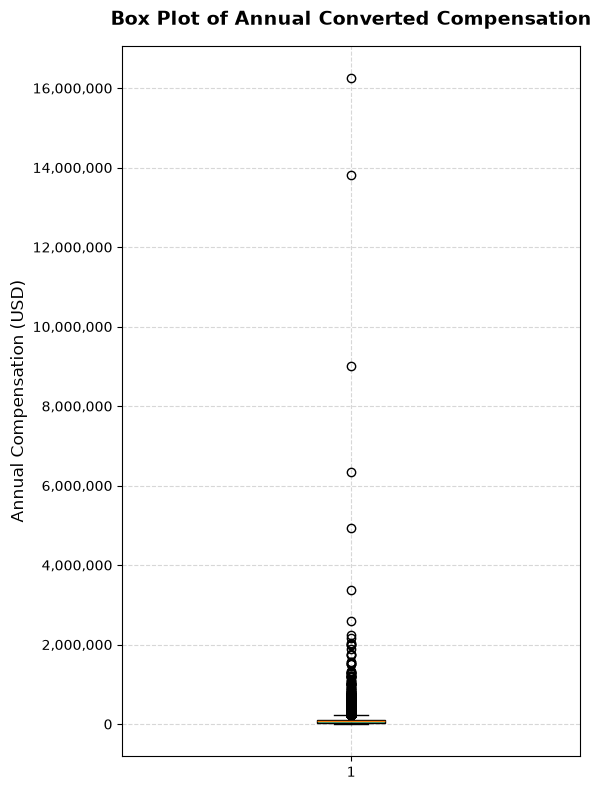

In [9]:
import matplotlib.pyplot as plt

# 1. Clean the data by pulling from the raw dataset, ignoring nulls
# (This ensures we use real currency numbers instead of decimal scales)
comp_data = df['ConvertedCompYearly'].dropna()

plt.figure(figsize=(6, 8))

# 2. Draw a clean, professional vertical box plot configuration
plt.boxplot(comp_data, patch_artist=True, boxprops=dict(facecolor='#1abc9c', color='black'))

# 3. Add proper chart formatting metadata
plt.title('Box Plot of Annual Converted Compensation', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Annual Compensation (USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# 4. Formats y-axis values to display commas for large currency amounts (e.g., 100,000)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()


<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [10]:
# 1. Create a new DataFrame excluding rows with outliers in ConvertedCompYearly
df_cleaned = df[(df['ConvertedCompYearly'] >= lower_bound) & (df['ConvertedCompYearly'] <= upper_bound)]

# 2. Validate the size of the new DataFrame safely using index integer parsing
print("=== DataFrame Size Validation ===")
print(f"Original dataset dimensions: {df.shape}")
print(f"Cleaned dataset dimensions:  {df_cleaned.shape}")

# Subtract just the row count numbers located at index 0 of the tuples
total_removed = df.shape[0] - df_cleaned.shape[0]
print(f"Total outlier rows successfully removed: {total_removed}")


=== DataFrame Size Validation ===
Original dataset dimensions: (65437, 116)
Cleaned dataset dimensions:  (22457, 116)
Total outlier rows successfully removed: 42980

<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


=== Calculated Pearson Correlation Matrix ===
                     Age_numeric  YearsCodePro_num  ConvertedCompYearly
Age_numeric               1.0000            0.7105               0.1208
YearsCodePro_num          0.7105            1.0000               0.1407
ConvertedCompYearly       0.1208            0.1407               1.0000
------------------------------------------------------------

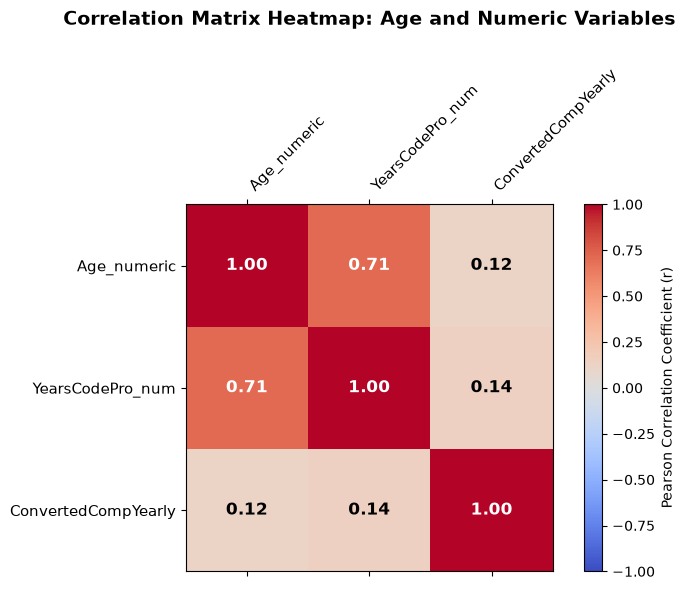

In [11]:
##Write your code here
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Map the Age text range column to approximate numeric midpoint values
age_mapping = { 
    "Under 18 years old": 17, 
    "18-24 years old": 21, 
    "25-34 years old": 29, 
    "35-44 years old": 39, 
    "45-54 years old": 49, 
    "55-64 years old": 59, 
    "65 years or older": 70 
} 
df['Age_numeric'] = df['Age'].map(age_mapping)

# Ensure essential structural comparison columns are converted to clean numbers safely
df['YearsCodePro_num'] = pd.to_numeric(
    df['YearsCodePro'].replace({'Less than 1 year': 0, 'More than 50 years': 50}), 
    errors='coerce'
).fillna(0)

# 2. Select numeric fields for the correlation matrix mapping
numeric_cols = ['Age_numeric', 'YearsCodePro_num', 'ConvertedCompYearly']
# Filter out any other existing numeric columns dynamically to make a robust matrix
extra_numeric = [c for c in df.columns if c in ['Respondent', 'CodeKnowledge', 'JobSat_numeric']]
cols_to_corr = [col for col in (numeric_cols + extra_numeric) if col in df.columns]

# 3. Compute correlations between Age and other numeric variables
corr_matrix = df[cols_to_corr].corr(method='pearson')
print("=== Calculated Pearson Correlation Matrix ===")
print(corr_matrix.round(4))
print("-" * 60)

# 4. Visualize the correlation matrix using a clean custom Matplotlib Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax, label='Pearson Correlation Coefficient (r)')

# Format axis ticks and labels perfectly
ax.set_xticks(np.arange(len(cols_to_corr)))
ax.set_yticks(np.arange(len(cols_to_corr)))
ax.set_xticklabels(cols_to_corr, rotation=45, ha='left', fontsize=11)
ax.set_yticklabels(cols_to_corr, fontsize=11)

# Overlay precise numeric correlation coefficient texts inside each matrix tile cell
for i in range(len(cols_to_corr)):
    for j in range(len(cols_to_corr)):
        val = corr_matrix.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha='center', va='center', 
                color='black' if abs(val) < 0.6 else 'white', fontweight='bold', fontsize=12)

plt.title('Correlation Matrix Heatmap: Age and Numeric Variables', fontsize=14, fontweight='bold', pad=30)
plt.tight_layout()
plt.show()


<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
